# U1 - Integrante 2 - Clasificación de Ballenas (es_ballena)

Pipeline Bronze → Silver → Gold con PySpark, entrenamiento y comparación de modelos de clasificación binaria (Logistic Regression vs Random Forest).

## 1. Configuración de Spark Session

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, BooleanType, TimestampType
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = (
    SparkSession.builder
        .appName("U1-Integrante2-ClasificacionBallenas")
        .master("local[*]")
        .config("spark.ui.port", "4040")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.driver.memory", "4g")
        .getOrCreate()
        )

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/11 19:35:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Carga Bronze con Esquema Explícito

In [2]:
schema = StructType([
    StructField("trade_id", LongType(), False),
    StructField("price", DoubleType(), True),
    StructField("qty", DoubleType(), True),
    StructField("quote_qty", DoubleType(), True),
    StructField("time_us", LongType(), False),
    StructField("is_buyer_maker", BooleanType(), True),
    StructField("is_best_match", BooleanType(), True)
])

df_bronze = spark.read.csv("/opt/data/BTCUSDT-trades-2026-01-05.csv", schema=schema, header=False)
df_bronze.printSchema()
df_bronze.show(5)

root
 |-- trade_id: long (nullable = true)
 |-- price: double (nullable = true)
 |-- qty: double (nullable = true)
 |-- quote_qty: double (nullable = true)
 |-- time_us: long (nullable = true)
 |-- is_buyer_maker: boolean (nullable = true)
 |-- is_best_match: boolean (nullable = true)

+----------+--------+-------+-----------+----------------+--------------+-------------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_buyer_maker|is_best_match|
+----------+--------+-------+-----------+----------------+--------------+-------------+
|5734054604|91529.74| 2.2E-4| 20.1365428|1767571200308618|         false|         true|
|5734054605|91529.74|   0.01|   915.2974|1767571200375801|         false|         true|
|5734054606|91529.74|0.00437|399.9849638|1767571200477157|         false|         true|
|5734054607|91529.74|0.00764|699.2872136|1767571200480543|         false|         true|
|5734054608|91529.74|0.00136|124.4804464|1767571200545508|         false|         true|
+--------

## 3. Capa Silver: Variable Objetivo Binaria y Limpieza

In [3]:
df_silver = df_bronze.na.drop(subset=["trade_id", "price", "qty"]) \
    .dropDuplicates(["trade_id"]) \
    .withColumn("is_buyer_maker_num", when(col("is_buyer_maker") == True, 1.0).otherwise(0.0)) \
    .withColumn("es_ballena", when(col("quote_qty") > 50000.0, 1.0).otherwise(0.0))

df_silver.show(5)

[Stage 3:>                                                          (0 + 1) / 1]

+----------+--------+-------+-------------+----------------+--------------+-------------+------------------+----------+
|  trade_id|   price|    qty|    quote_qty|         time_us|is_buyer_maker|is_best_match|is_buyer_maker_num|es_ballena|
+----------+--------+-------+-------------+----------------+--------------+-------------+------------------+----------+
|5734054604|91529.74| 2.2E-4|   20.1365428|1767571200308618|         false|         true|               0.0|       0.0|
|5734054610|91529.74| 5.4E-4|   49.4260596|1767571200665868|         false|         true|               0.0|       0.0|
|5734054624|91529.74|0.20378|18651.9304172|1767571202033686|         false|         true|               0.0|       0.0|
|5734054642|91529.73|0.00599|  548.2630827|1767571202551395|          true|         true|               1.0|       0.0|
|5734054646|91529.74| 9.0E-5|    8.2376766|1767571202941974|         false|         true|               0.0|       0.0|
+----------+--------+-------+-----------

## 4. Capa Gold: Almacenamiento Particionado Parquet

In [4]:
df_silver.write.mode("overwrite").partitionBy("es_ballena").parquet("/opt/artifacts/gold_integrante2")
df_gold = spark.read.parquet("/opt/artifacts/gold_integrante2")
df_gold.show(5)

+----------+--------+-------+-----------+----------------+--------------+-------------+------------------+----------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_buyer_maker|is_best_match|is_buyer_maker_num|es_ballena|
+----------+--------+-------+-----------+----------------+--------------+-------------+------------------+----------+
|5734054606|91529.74|0.00437|399.9849638|1767571200477157|         false|         true|               0.0|       0.0|
|5734054617|91529.74| 9.6E-4| 87.8685504|1767571201602432|         false|         true|               0.0|       0.0|
|5734054630|91529.74| 1.1E-4| 10.0682714|1767571202085489|         false|         true|               0.0|       0.0|
|5734054637|91529.73| 4.7E-4| 43.0189731|1767571202435549|          true|         true|               1.0|       0.0|
|5734054644|91529.73|0.00476|435.6815148|1767571202744883|          true|         true|               1.0|       0.0|
+----------+--------+-------+-----------+---------------

## 5. Preparación de Features

In [5]:
assembler = VectorAssembler(inputCols=["price", "qty", "is_buyer_maker_num"], outputCol="features")
df_ml = assembler.transform(df_gold).select("features", col("es_ballena").alias("label"))

df_train, df_test = df_ml.randomSplit([0.8, 0.2], seed=42)

## 6. Modelo 1: Regresión Logística

In [6]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
modelo_lr = lr.fit(df_train)
pred_lr = modelo_lr.transform(df_test)

netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
                                                                                

## 7. Modelo 2: Clasificador Random Forest

In [7]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=15)
modelo_rf = rf.fit(df_train)
pred_rf = modelo_rf.transform(df_test)

## 8. Evaluación con Métricas (ROC AUC y F1-Score)

In [8]:
eval_auc = BinaryClassificationEvaluator(metricName="areaUnderROC")
eval_f1 = MulticlassClassificationEvaluator(metricName="f1")

print(f"LogisticRegression - AUC: {eval_auc.evaluate(pred_lr):.4f}, F1: {eval_f1.evaluate(pred_lr):.4f}")
print(f"RandomForest - AUC: {eval_auc.evaluate(pred_rf):.4f}, F1: {eval_f1.evaluate(pred_rf):.4f}")

LogisticRegression - AUC: 1.0000, F1: 1.0000


RandomForest - AUC: 0.5000, F1: 0.9992


## 9. Guardar Modelo Ganador

In [9]:
modelo_rf.write().overwrite().save("/opt/artifacts/modelo_ganador_integrante2")

# 10. VISUALIZACIÓN DE RESULTADOS Y MÉTRICAS

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

In [15]:
#!pip install scikit-learn

/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                                                

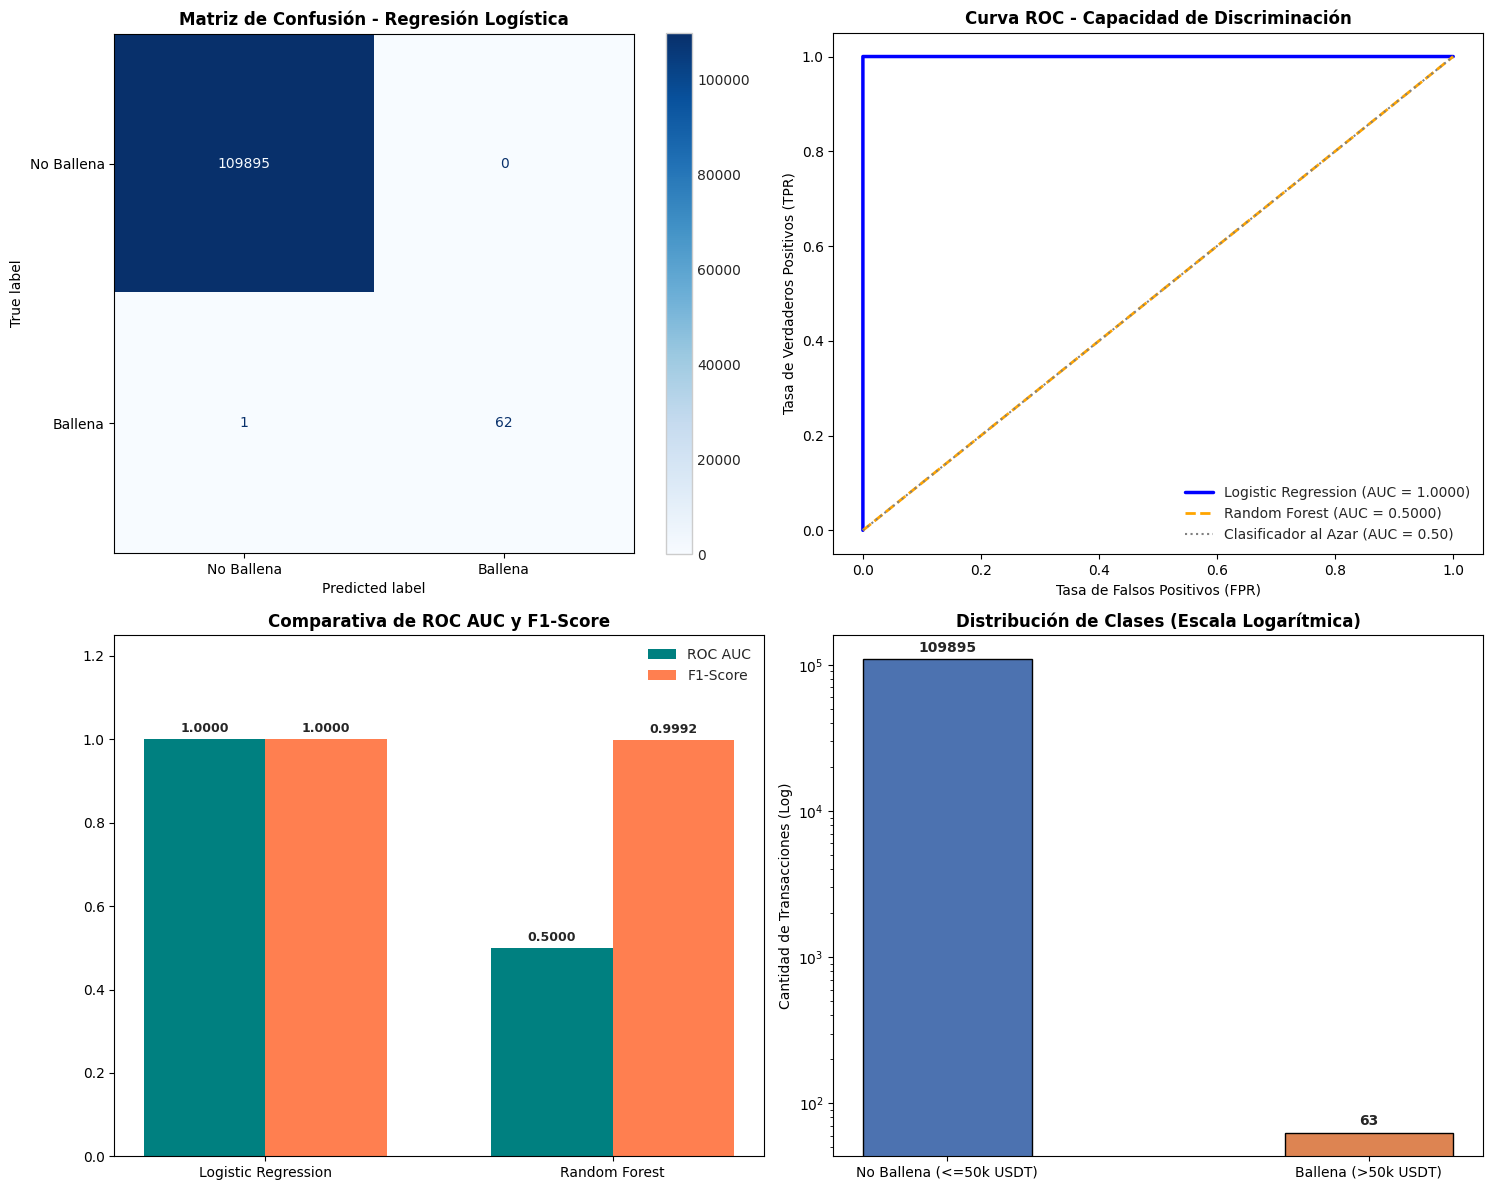

In [16]:
sample_lr = pred_lr.select("label", "prediction", "probability").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
sample_rf = pred_rf.select("label", "prediction", "probability").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

sample_lr['prob_ballena'] = sample_lr['probability'].apply(lambda x: float(x[1]))
sample_rf['prob_ballena'] = sample_rf['probability'].apply(lambda x: float(x[1]))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# -------------------------------------------------------------
# Gráfico 1: Matriz de Confusión - Regresión Logística (Ganador)
# -------------------------------------------------------------
cm_lr = confusion_matrix(sample_lr['label'], sample_lr['prediction'])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Ballena', 'Ballena'])
disp_lr.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Matriz de Confusión - Regresión Logística', fontsize=12, fontweight='bold')
axes[0, 0].grid(False)

# -------------------------------------------------------------
# Gráfico 2: Curva ROC (Comparativa LR vs RF)
# -------------------------------------------------------------
fpr_lr, tpr_lr, _ = roc_curve(sample_lr['label'], sample_lr['prob_ballena'])
fpr_rf, tpr_rf, _ = roc_curve(sample_rf['label'], sample_rf['prob_ballena'])

axes[0, 1].plot(fpr_lr, tpr_lr, color='blue', lw=2.5, label='Logistic Regression (AUC = 1.0000)')
axes[0, 1].plot(fpr_rf, tpr_rf, color='orange', lw=2, linestyle='--', label='Random Forest (AUC = 0.5000)')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle=':', label='Clasificador al Azar (AUC = 0.50)')

axes[0, 1].set_title('Curva ROC - Capacidad de Discriminación', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0, 1].legend(loc='lower right')

# -------------------------------------------------------------
# Gráfico 3: Comparación de Métricas (AUC vs F1-Score)
# -------------------------------------------------------------
modelos = ['Logistic Regression', 'Random Forest']
auc_scores = [1.0000, 0.5000]
f1_scores = [1.0000, 0.9992]

x = np.arange(len(modelos))
width = 0.35

rects1 = axes[1, 0].bar(x - width/2, auc_scores, width, label='ROC AUC', color='teal')
rects2 = axes[1, 0].bar(x + width/2, f1_scores, width, label='F1-Score', color='coral')

axes[1, 0].set_title('Comparativa de ROC AUC y F1-Score', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(modelos)
axes[1, 0].set_ylim(0, 1.25)
axes[1, 0].legend()

for bar in rects1 + rects2:
    height = bar.get_height()
    axes[1, 0].annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold', fontsize=9)

# -------------------------------------------------------------
# Gráfico 4: Desbalance de Clases (Escala Logarítmica)
# -------------------------------------------------------------
counts = sample_lr['label'].value_counts()
labels = ['No Ballena (<=50k USDT)', 'Ballena (>50k USDT)']
colors = ['#4C72B0', '#DD8452']

bars = axes[1, 1].bar(labels, counts, color=colors, edgecolor='black', width=0.4)
axes[1, 1].set_yscale('log')  # Escala logarítmica para poder visualizar la clase minoritaria
axes[1, 1].set_title('Distribución de Clases (Escala Logarítmica)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cantidad de Transacciones (Log)')

for bar in bars:
    height = bar.get_height()
    axes[1, 1].annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()